# Stage 3 — Performance Comparison: Neural vs Fixed Baselines

Analyses the performance and accuracy of the Stage 3 Neural LOD system (4 thresholds) and compares it against standard Fixed-Quality baselines.

**Goals**:
1. Compare 4 predicted thresholds against geometric Oracle thresholds (if available).
2. Benchmark runtime performance (CPU/GPU/FPS) against Fixed Quality presets.
3. Analyze LOD Stability over time (flickering metrics).

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
print('Libraries loaded OK')

Libraries loaded OK


In [29]:
BASE_DIR = Path('../..').resolve()
EVAL_DIR = BASE_DIR / 'data' / 'Baker_Eval_3'
BASELINE_DIR = BASE_DIR / 'data' / 'BaseLine'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_3' / 'Eval'
OBJECTS_FILE = BASE_DIR / 'data' / 'Baker_2' / 'lod_objects.csv'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_COLORS = {
    'neural_4thresh':     '#2196F3',
    'neural_baker_4val':  '#2196F3',
    'fixed_default':      '#4CAF50',
    'fixed_aggressive':   '#FF9800',
}
DEFAULT_COLOR = '#9C27B0'

FRAME_BUDGET_MS = 16.67 # 60 FPS

## 1. Load Data (Neural & Baselines)

In [30]:
csv_files = list(EVAL_DIR.glob('inference_eval_*.csv')) + list(BASELINE_DIR.glob('inference_eval_*.csv'))
print(f'Found {len(csv_files)} evaluation files.')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    df['source_file'] = f.name
    dfs.append(df)

if not dfs:
    raise FileNotFoundError("No evaluation files found.")

data = pd.concat(dfs, ignore_index=True)

# Ensure numeric columns for 4 thresholds
threshold_cols = ['predicted_t0', 'predicted_t1', 'predicted_t2', 'predicted_t3']
numeric_cols = ['frame', 'cpu_ms', 'gpu_ms', 'fps', 'inference_duration_ms', 'lod_bias_applied'] + threshold_cols
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print(f'Loaded {len(data)} frames across {data[ "run_label" ].nunique()} runs.')
runs = sorted(data['run_label'].unique())
data.head()

Found 3 evaluation files.
Loaded 12385 frames across 3 runs.


,run_label,frame,cpu_ms,gpu_ms,fps,inference_duration_ms,predicted_t0,predicted_t1,predicted_t2,predicted_t3,...,lod_bias_applied,threshold_changed,cam_pos_x,cam_pos_y,cam_pos_z,cam_rot_x,cam_rot_y,cam_rot_z,source_file,predicted_threshold
0,neural_4thresh,0,11.3101,0.0000,54.9943,0.5179,0.1084,0.021833,0.002327,0.0,...,2.0,0,35.6101,2.4967,33.3750,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv,NaN
1,neural_4thresh,1,17.1718,8.0865,17.1498,0.5179,0.1084,0.021833,0.002327,0.0,...,2.0,0,35.6049,2.5214,33.0770,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv,NaN
2,neural_4thresh,2,7.3382,0.0000,85.3774,0.5179,0.1084,0.021833,0.002327,0.0,...,2.0,0,35.6030,2.5291,32.9773,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv,NaN
3,neural_4thresh,3,55.6253,9.7147,38.9622,0.5179,0.1084,0.021833,0.002327,0.0,...,2.0,0,35.6011,2.5358,32.8775,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv,NaN
4,neural_4thresh,4,19.6320,8.7665,73.3730,0.5179,0.1084,0.021833,0.002327,0.0,...,2.0,0,35.5991,2.5426,32.7778,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv,NaN


## 2. Oracle Generation (Accuracy Benchmark)
Stage 3 predicts transition heights. We derive the Oracle heights based on the `optimal_lod` logic used during training.

In [31]:
df_objects = pd.read_csv(OBJECTS_FILE)
qual_map = {0: 1.0, 1: 0.8, 2: 0.6, 3: 0.4}

# Parse base thresholds from objects.csv
all_thresholds = []
for t_str in df_objects['thresholds']:
    vals = [float(v) for v in str(t_str).split(';') if v.strip()]
    if len(vals) < 4: vals += [0.001] * (4 - len(vals))
    all_thresholds.append(vals[:4])
base_vector = np.mean(all_thresholds, axis=0)

def calculate_oracle_vector(optimal_lod):
    mult = qual_map.get(int(optimal_lod), 0.4)
    return base_vector * mult

# Generate ground truth for eval data if optimal_lod is present
if 'optimal_lod' in data.columns:
    oracles = np.array([calculate_oracle_vector(lod) for lod in data['optimal_lod']])
    for i in range(4):
        data[f'oracle_threshold_{i}'] = oracles[:, i]
    print("✓ Oracle thresholds generated.")
else:
    print("ℹ Oracle comparison skipped: Evaluation data does not contain ground truth 'optimal_lod' labels.")

ℹ Oracle comparison skipped: Evaluation data does not contain ground truth 'optimal_lod' labels.


## 3. Summary Performance Matrix

In [32]:
def percentile(series, p):
    return float(np.percentile(series.dropna(), p))

summary_rows = []
for run in runs:
    df = data[data['run_label'] == run]
    cpu = df['cpu_ms']
    gpu = df['gpu_ms']
    fps = df['fps']
    inf = df['inference_duration_ms'] if 'inference_duration_ms' in df.columns else pd.Series([0])
    lod = df['lod_bias_applied'] if 'lod_bias_applied' in df.columns else pd.Series([1])

    # LOD flip rate
    lod_vals = lod.values
    switches = sum(1 for i in range(1, len(lod_vals)) if abs(lod_vals[i] - lod_vals[i-1]) > 0.001)
    duration_s = len(df) / fps.mean() if fps.mean() > 0 else 1
    flip_rate = switches / duration_s if duration_s > 0 else 0

    # frames over budget
    over_budget_pct = 100 * (cpu > FRAME_BUDGET_MS).sum() / len(cpu)

    summary_rows.append({
        'run_label':         run,
        'frames':            len(df),
        'mean_cpu_ms':       round(cpu.mean(), 3),
        'p95_cpu_ms':        round(percentile(cpu, 95), 3),
        'p99_cpu_ms':        round(percentile(cpu, 99), 3),
        'mean_gpu_ms':       round(gpu.mean(), 3),
        'p95_gpu_ms':        round(percentile(gpu, 95), 3),
        'p99_gpu_ms':        round(percentile(gpu, 99), 3),
        'mean_fps':          round(fps.mean(), 2),
        'p5_fps':            round(percentile(fps, 5), 2),
        'mean_inference_ms': round(inf.mean(), 4),
        'lod_switches':      switches,
        'flip_rate_per_s':   round(flip_rate, 3),
        'over_budget_pct':   round(over_budget_pct, 1),
    })

summary = pd.DataFrame(summary_rows).set_index('run_label')
print('=== Performance Comparison Summary ===')
display(summary.T)

=== Performance Comparison Summary ===


run_label,fixed_aggressive,fixed_default,neural_4thresh
frames,4225.000,3914.000,4246.0000
mean_cpu_ms,16.666,16.666,16.7230
p95_cpu_ms,17.032,17.048,17.0620
p99_cpu_ms,17.250,17.390,19.6440
mean_gpu_ms,4.683,5.218,5.3570
p95_gpu_ms,5.657,6.402,7.1830
p99_gpu_ms,6.021,6.761,7.4930
mean_fps,60.000,60.000,60.4600
p5_fps,59.740,59.730,59.8500
mean_inference_ms,0.000,0.000,0.1392


## 4. CPU/GPU Frame Time Comparison

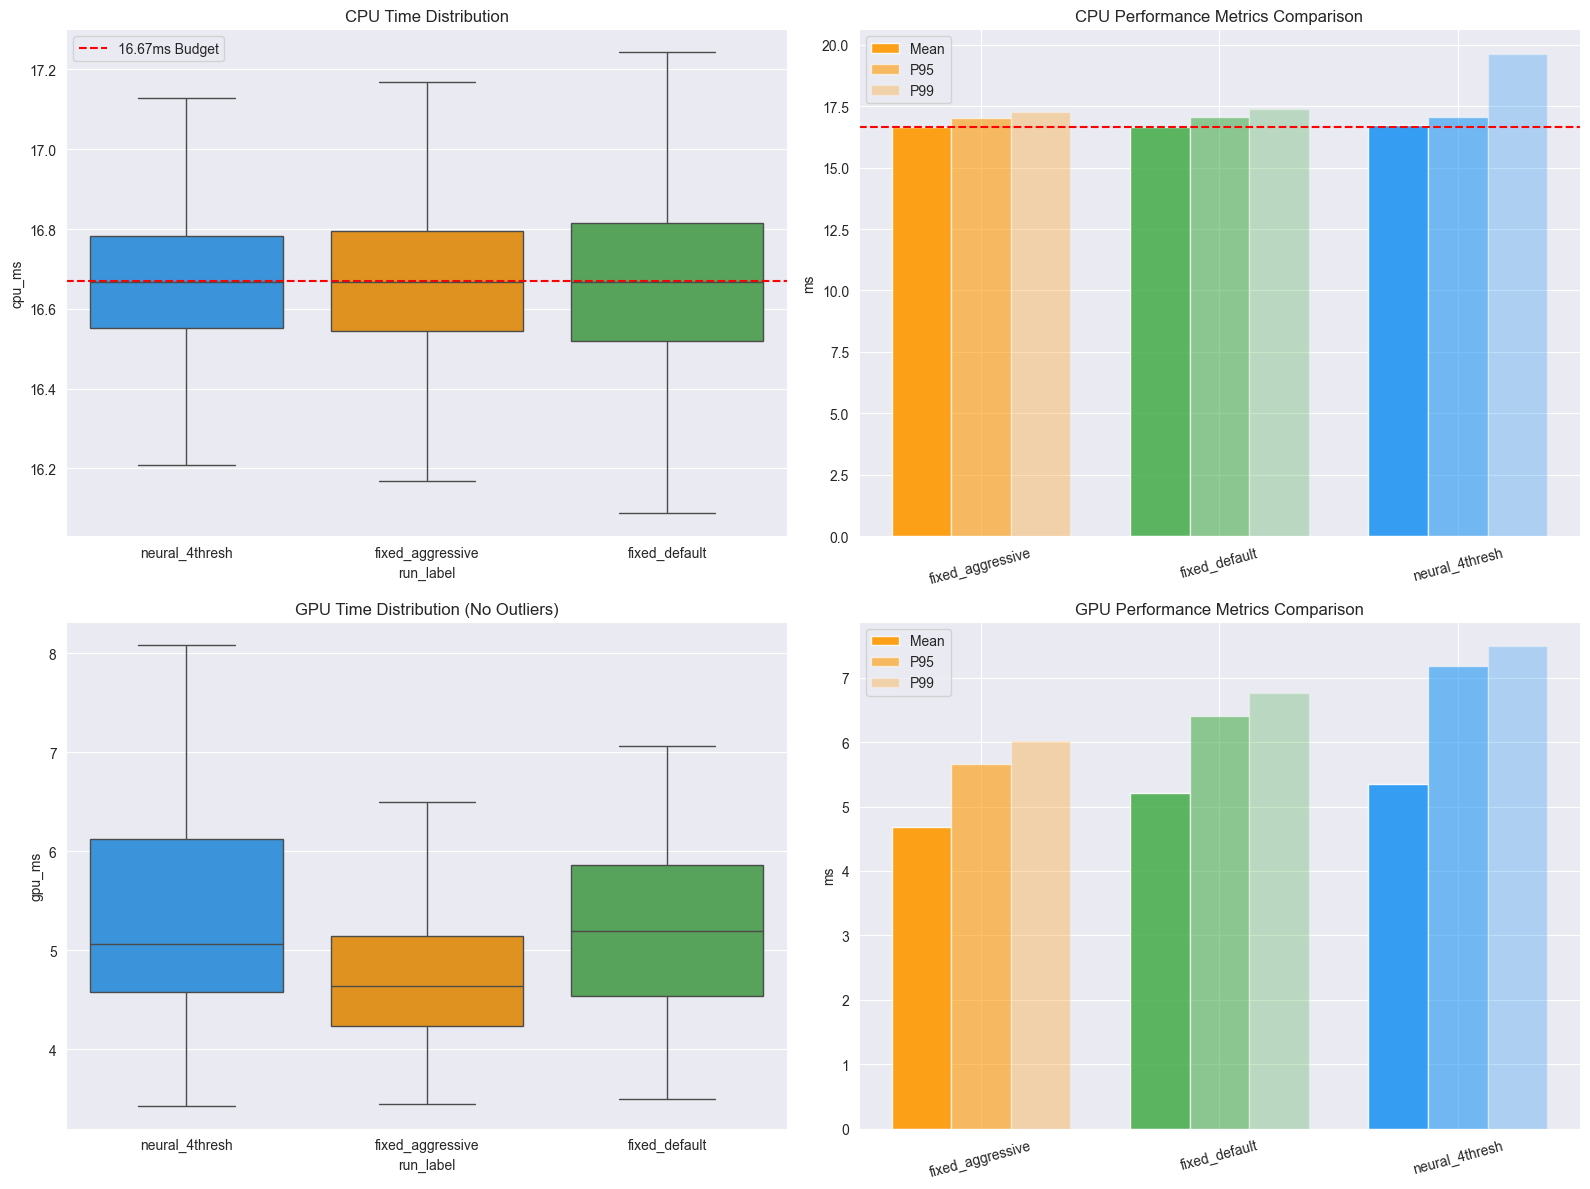

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = {label: RUN_COLORS.get(label, DEFAULT_COLOR) for label in data['run_label'].unique()}

# CPU Time Boxplots
ax = axes[0, 0]
sns.boxplot(data=data, x='run_label', y='cpu_ms', palette=palette, ax=ax, showfliers=False)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', label=f'{FRAME_BUDGET_MS}ms Budget')
ax.set_title('CPU Time Distribution')
ax.legend()

# CPU Time Comparison Bar
ax = axes[0, 1]
x = np.arange(len(runs))
w = 0.25
means = [summary.loc[r, 'mean_cpu_ms'] for r in runs]
p95s  = [summary.loc[r, 'p95_cpu_ms']  for r in runs]
p99s  = [summary.loc[r, 'p99_cpu_ms']  for r in runs]
ax.bar(x - w, means, w, label='Mean', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x,     p95s,  w, label='P95',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s,  w, label='P99',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--')
ax.set_title('CPU Performance Metrics Comparison')
ax.set_ylabel('ms')
ax.legend()

# GPU Time Boxplots
ax = axes[1, 0]
sns.boxplot(data=data, x='run_label', y='gpu_ms', palette=palette, ax=ax, showfliers=False)
ax.set_title('GPU Time Distribution (No Outliers)')

# GPU Time Comparison Bar
ax = axes[1, 1]
means = [summary.loc[r, 'mean_gpu_ms'] for r in runs]
p95s  = [summary.loc[r, 'p95_gpu_ms']  for r in runs]
p99s  = [summary.loc[r, 'p99_gpu_ms']  for r in runs]
ax.bar(x - w, means, w, label='Mean', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x,     p95s,  w, label='P95',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s,  w, label='P99',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.set_title('GPU Performance Metrics Comparison')
ax.set_ylabel('ms')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_comparison_matrix.png')
plt.show()

## 5. FPS Stability Comparison

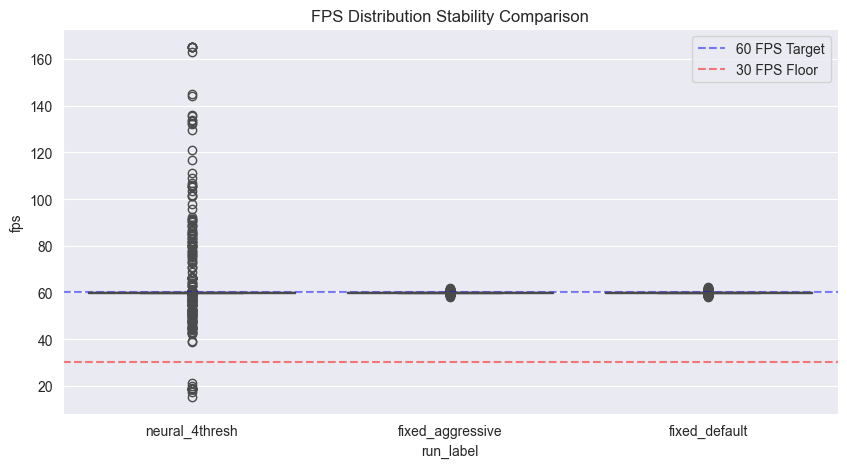

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='run_label', y='fps', palette=palette, showfliers=True)
plt.axhline(60, color='blue', linestyle='--', alpha=0.5, label='60 FPS Target')
plt.axhline(30, color='red', linestyle='--', alpha=0.5, label='30 FPS Floor')
plt.title('FPS Distribution Stability Comparison')
plt.legend()
plt.savefig(PLOTS_DIR / 'fps_comparison.png')
plt.show()

## 6. LOD Stability & Flip Frequency

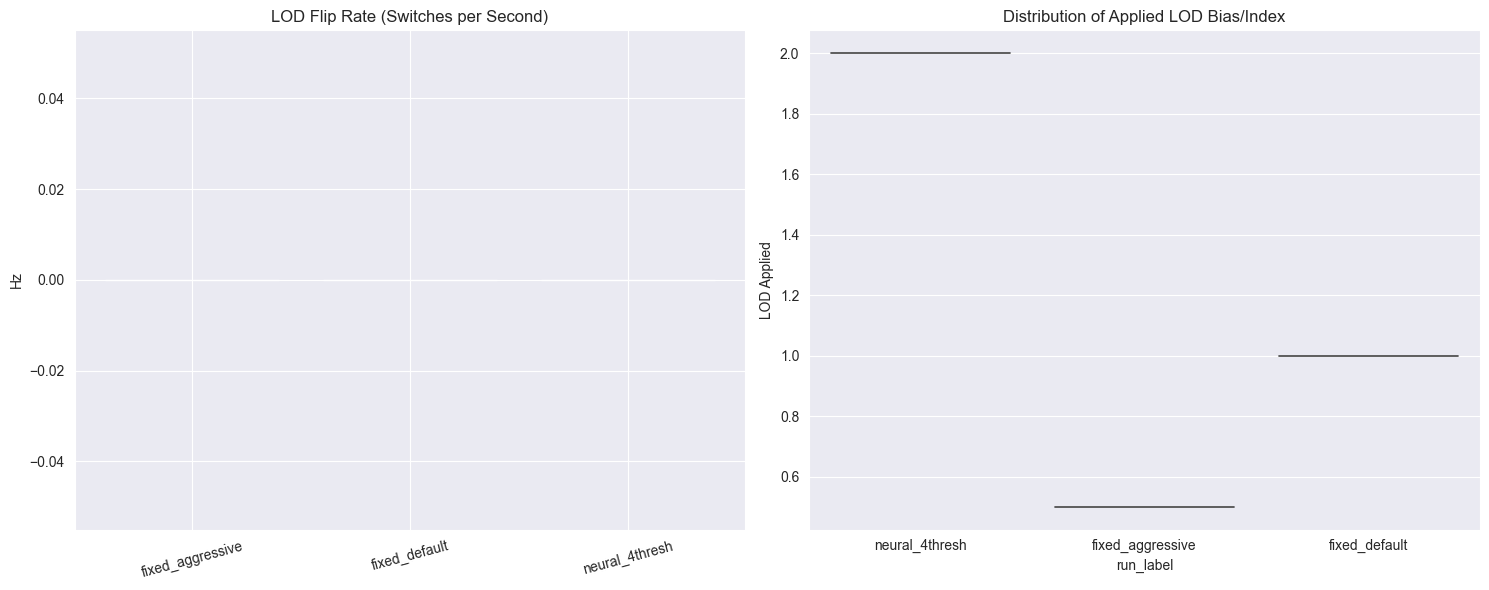

[np.float64(0.0), np.float64(0.0), np.float64(0.0)]
run_label
fixed_aggressive    0.0
fixed_default       0.0
neural_4thresh      0.0
Name: flip_rate_per_s, dtype: float64


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Flip Rate Bar
ax = axes[0]
x = np.arange(len(runs))
rates = [summary.loc[r, 'flip_rate_per_s'] for r in runs]
ax.bar(x, rates, color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.set_title('LOD Flip Rate (Switches per Second)')
ax.set_ylabel('Hz')

# 2. Applied LOD Distribution
ax = axes[1]
sns.violinplot(data=data, x='run_label', y='lod_bias_applied', palette=palette, ax=ax)
ax.set_title('Distribution of Applied LOD Bias/Index')
ax.set_ylabel('LOD Applied')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'lod_stability_analysis.png')
plt.show()
print(rates)
print(summary['flip_rate_per_s'])

## 7. Performance Purity (CDF Plots)

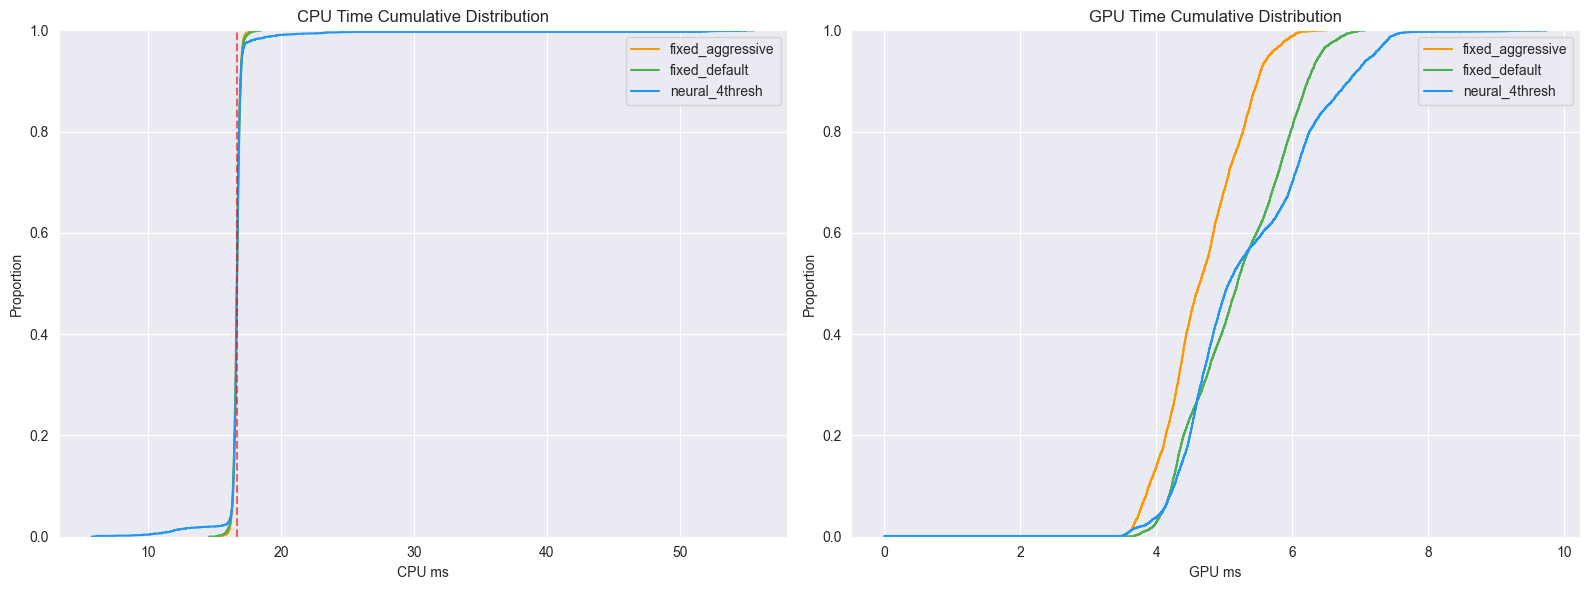

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CPU CDF
ax = axes[0]
for run in runs:
    subset = data[data['run_label'] == run]['cpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR), ax=ax)
ax.axvline(FRAME_BUDGET_MS, color='red', linestyle='--', alpha=0.6)
ax.set_title('CPU Time Cumulative Distribution')
ax.set_xlabel('CPU ms')
ax.legend()

# GPU CDF
ax = axes[1]
for run in runs:
    subset = data[data['run_label'] == run]['gpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR), ax=ax)
ax.set_title('GPU Time Cumulative Distribution')
ax.set_xlabel('GPU ms')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_cdf.png')
plt.show()